In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
import sys

# Setting the root folder
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

# --- Other Imports
from src.import_dataframe import import_dataframe
from src.plot_meldefined_magnitudes_per_class import plot_meldefined_magnitudes_per_class
from src.plot_acoustic_features import plot_acoustic_features
from src.build_X import build_X
from src.apply_block_pca import apply_block_pca
from src.run_cv_experiment import run_cv_experiment
from src.extra_plot_results_bar import extra_plot_results_bar
from src.extra_build_table_accuracies import extra_build_table_accuracies
from src.extra_plot_3_confusion_matrices import extra_plot_3_confusion_matrices



In [2]:
# import dataframe
df = import_dataframe("mysMEEI")


# Verify columns
print(df.columns)

Index(['file', 'age', 'gender', 'group', 'class', 'localJitter',
       'localShimmer', 'HNR', 'MFBM'],
      dtype='object')


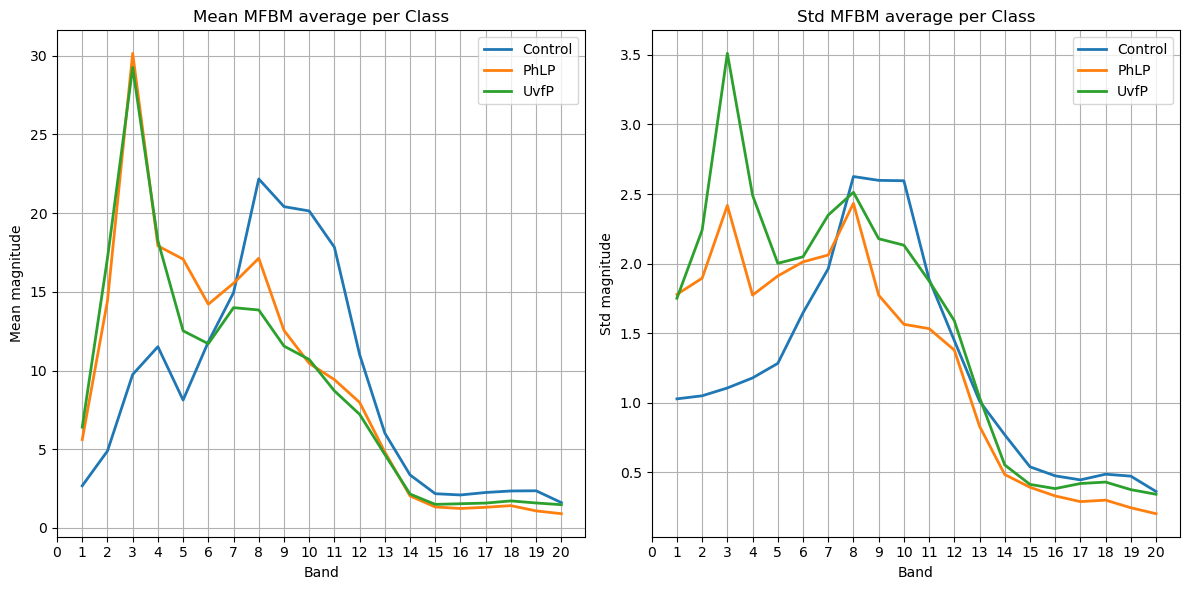

In [3]:
# Calculating band magnitude mean and std dev and adding to dataframe
# These are the features used in the Article

mean_list = []
std_list = []

for mfbm in df['MFBM']:

    # mfbm shape: (n_filters, n_frames)

    mean_bands = np.mean(mfbm, axis=1)  # (20,)
    std_bands = np.std(mfbm, axis=1)    # (20,)

    mean_list.append(mean_bands)
    std_list.append(std_bands)

df['mean_MFBM'] = mean_list
df['std_MFBM'] = std_list


# The Article joined the edema and nodules classes into one, PhLP
# Merging edema and nodules into 'PhLP' class
df.loc[df['group'].isin(['edema', 'nodulo']), 'group'] = 'PhLP'
df.loc[df['group'].isin(['UVFP']), 'group'] = 'UvfP'
df.loc[df['group'].isin(['control']), 'group'] = 'Control'
#df.loc[df['class'] == 3, 'class'] = 1



# Recalculate class codes from scratch after merge
df['class'] = pd.Categorical(df['group']).codes


# Plotting mean and std magintudes per band, per class
plot_meldefined_magnitudes_per_class(
    df,
    save_path = "../results/figures/02mel_bands_per_class.png"
)


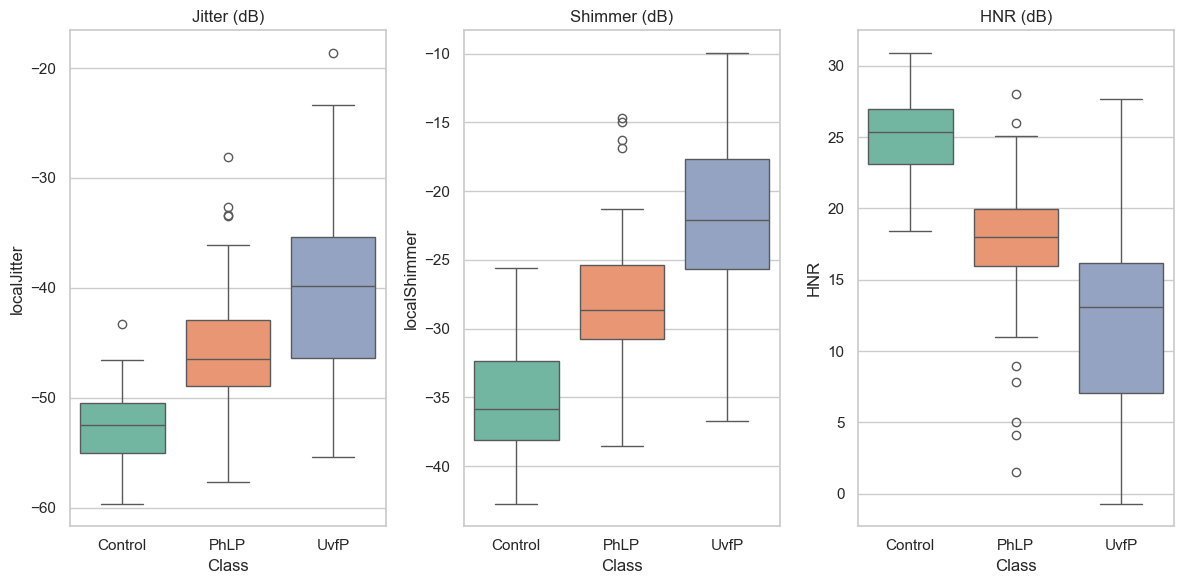

In [4]:
# Show acoustic features per class boxplots
# Jitter and shimmer were converted to dB
# for better visualization

features = [
    ("localJitter", "Jitter (dB)"),
    ("localShimmer", "Shimmer (dB)"),
    ("HNR", "HNR (dB)")
]

plot_acoustic_features(df,
                       features,
                       save_path = "../results/figures/03acoustic_features_per_class.png"
                      )

In [5]:
# ------------------------------------------------------------------
# Experiment grid
# ------------------------------------------------------------------

# Feature sets to evaluate — each will be tested on every task
feature_sets = ["acoustic", "spectral", "all"]

# Classification tasks — each entry maps a task name to the two groups
# involved. None means all classes are used (3-class classification).
tasks = {
    "Control_vs_PhLP": ["Control", "PhLP"],
    "Control_vs_UVFP": ["Control", "UvfP"],
    "PhLP_vs_UVFP":    ["PhLP", "UvfP"],
    "All_classes":     None                 # all three classes
}

# ------------------------------------------------------------------
# Run all experiments
# ------------------------------------------------------------------
results = []

for task_name, groups in tasks.items():

    # Filter dataset to the relevant classes for this task.
    # For the 3-class task, the full dataset is used as-is.
    if groups is None:
        df_task = df.copy()
    else:
        df_task = df[df["group"].isin(groups)].copy()

    # Encode group labels as integer class codes.
    # pd.Categorical preserves a consistent mapping within each task.
    df_task["class"] = pd.Categorical(df_task["group"]).codes

    X = build_X(df_task)       # feature matrix — shape (n_samples, 27)
    y = df_task["class"].values

    # Run cross-validation for each feature set
    for feat in feature_sets:

        metrics = run_cv_experiment(
            X, y,
            feature_set=feat,
            print_report=True
        )

        # Store results alongside task and feature set identifiers
        results.append({
            "task":     task_name,
            "features": feat,
            **metrics
        })

# ------------------------------------------------------------------
# Collect all results into a single DataFrame for analysis and export
# ------------------------------------------------------------------
results_df = pd.DataFrame(results)

Accuracy : 0.8480869565217393
Std Acc  : 0.008985811121556433
Precision: 0.8027175606639596
Recall   : 0.8111388888866357
F1       : 0.8068060975610606
AUC      : 0.9077876984126984

Confusion Matrix (average over iterations)
 [[29.201  6.799]
 [ 7.177 48.823]]

Normalised Confusion Matrix (average over iterations)
 [[0.81113889 0.18886111]
 [0.12816071 0.87183929]]

Accuracy : 0.8646304347826087
Std Acc  : 0.023062656088579932
Precision: 0.819144434749241
Recall   : 0.8401944444421106
F1       : 0.8289941893098043
AUC      : 0.9293065476190476

Confusion Matrix (average over iterations)
 [[30.247  5.753]
 [ 6.701 49.299]]

Normalised Confusion Matrix (average over iterations)
 [[0.84019444 0.15980556]
 [0.11966071 0.88033929]]

Accuracy : 0.9448804347826087
Std Acc  : 0.01063862825523663
Precision: 0.9155631227824879
Recall   : 0.9464444444418154
F1       : 0.9306107975108423
AUC      : 0.9648110119047619

Confusion Matrix (average over iterations)
 [[34.072  1.928]
 [ 3.143 52.857]]


In [6]:
# Show results
print(results_df)

# Export results
results_df.to_csv("../results/metrics/summary.csv", sep=";", index=False)


               task  features  accuracy_mean  accuracy_std  precision  \
0   Control_vs_PhLP  acoustic       0.848087      0.008986   0.802718   
1   Control_vs_PhLP  spectral       0.864630      0.023063   0.819144   
2   Control_vs_PhLP       all       0.944880      0.010639   0.915563   
3   Control_vs_UVFP  acoustic       0.906989      0.006464   0.830292   
4   Control_vs_UVFP  spectral       0.864916      0.018816   0.815859   
5   Control_vs_UVFP       all       0.931295      0.005700   0.854758   
6      PhLP_vs_UVFP  acoustic       0.685791      0.012005   0.652103   
7      PhLP_vs_UVFP  spectral       0.679087      0.024195   0.648044   
8      PhLP_vs_UVFP       all       0.726687      0.017012   0.704371   
9       All_classes  acoustic       0.668629      0.010212   0.805862   
10      All_classes  spectral       0.670609      0.021950   0.836427   
11      All_classes       all       0.745894      0.014670   0.894285   

      recall        f1       auc  \
0   0.811139  

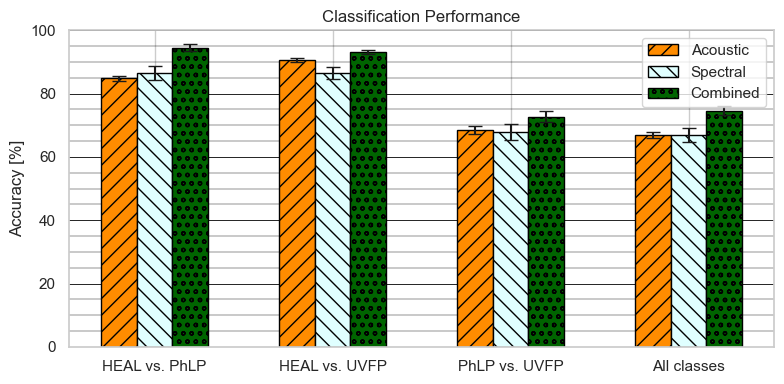

In [7]:
# Plot accuracies bar graph
extra_plot_results_bar(results_df, "../results/figures/04accuracies_bar.png")

In [8]:
# Make, show and save Accuracies Table

table1 = extra_build_table_accuracies(results_df)

table1.to_csv("../results/metrics/accuracies.csv", index=False, sep=";")

print(table1)

  Classification   HE vs. PhLP   HE vs. UVFP PhLP vs. UVFP       3-Class  \
0       Acoustic  84.81 ± 0.90  90.70 ± 0.65  68.58 ± 1.20  66.86 ± 1.02   
1       Spectral  86.46 ± 2.31  86.49 ± 1.88  67.91 ± 2.42  67.06 ± 2.19   
2       Combined  94.49 ± 1.06  93.13 ± 0.57  72.67 ± 1.70  74.59 ± 1.47   

  HE vs. All (*) PhLP vs. All (*) UVFP vs. All (*)  
0   88.25 ± 0.55     69.51 ± 1.03     75.97 ± 0.90  
1   87.97 ± 1.08     72.89 ± 2.11     73.26 ± 2.03  
2   92.96 ± 0.64     77.46 ± 1.53     78.76 ± 1.33  


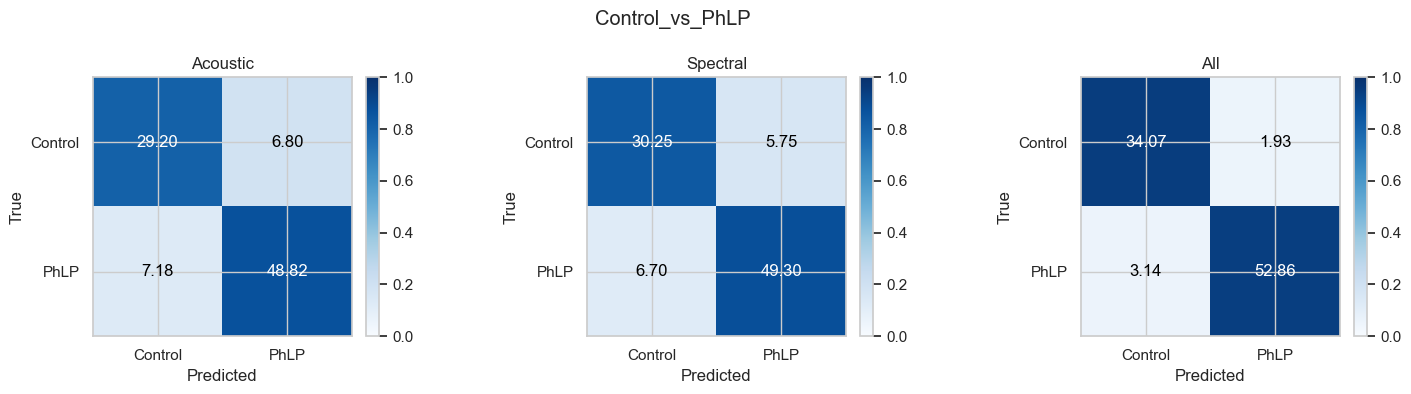

In [9]:
extra_plot_3_confusion_matrices(
    results_df,
    task_name="Control_vs_PhLP",
    class_names=["Control", "PhLP"]
)

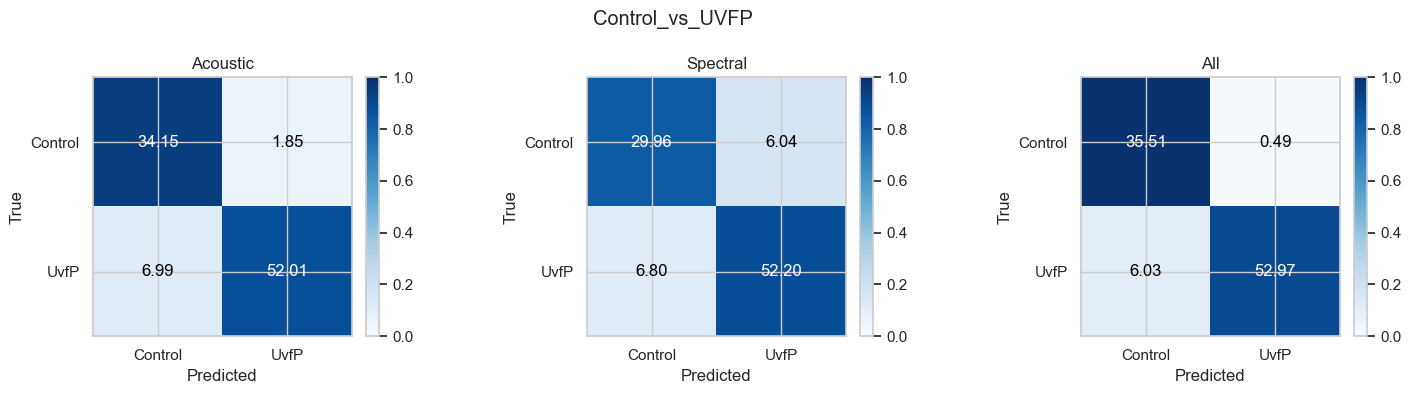

In [10]:
extra_plot_3_confusion_matrices(
    results_df,
    task_name="Control_vs_UVFP",
    class_names=["Control", "UvfP"]
)


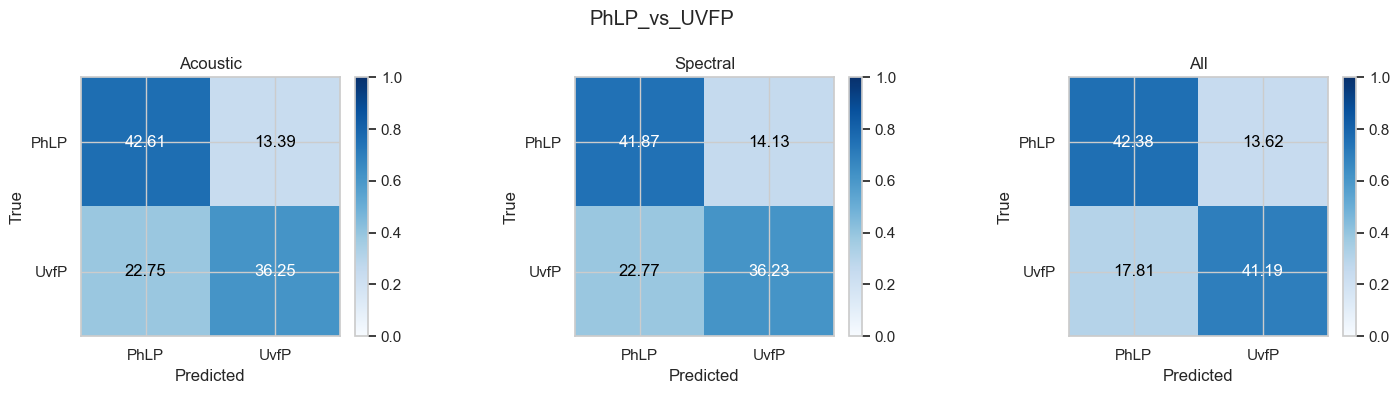

In [11]:
extra_plot_3_confusion_matrices(
    results_df,
    task_name="PhLP_vs_UVFP",
    class_names=["PhLP", "UvfP"]
)

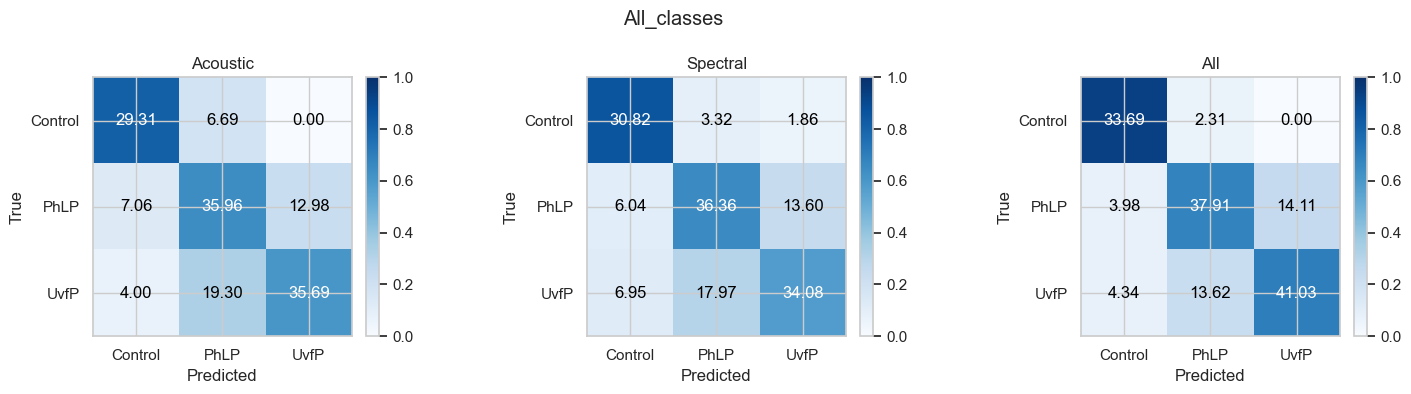

In [12]:
extra_plot_3_confusion_matrices(
    results_df,
    task_name="All_classes",
    class_names=["Control", "PhLP", "UvfP"]
)